In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/kaggle/input/spam-dataset/spam.csv',encoding = "ISO-8859-1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
922,ham,It shall be fine. I have avalarr now. Will hol...,NaN,NaN,NaN
5161,ham,Lol no. I just need to cash in my nitros. Hurr...,NaN,NaN,NaN
2497,ham,Dai what this da.. Can i send my resume to thi...,NaN,NaN,NaN
1603,ham,Have you heard about that job? I'm going to th...,NaN,NaN,NaN
1610,ham,I'll probably be around mu a lot,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

**Data Cleaning**

In [5]:
df.info

<bound method DataFrame.info of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

**Delete unnecessary columns**

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.sample(5)

,v1,v2
1389,ham,"Haha... Where got so fast lose weight, thk muz..."
5357,ham,Ok
2900,spam,Ur cash-balance is currently 500 pounds - to m...
3927,ham,Babe ? I lost you ... Will you try rebooting ?
1541,ham,Do u konw waht is rael FRIENDSHIP Im gving yuo...


**Rename Columns**

In [8]:
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)
df.sample(5)

,Target,Text
5239,ham,"Jay wants to work out first, how's 4 sound?"
4862,spam,Bored housewives! Chat n date now! 0871750.77....
2240,ham,K I'll call you when I'm close
4675,ham,ÌÏ ready then call me...
1115,ham,So lets make it saturday or monday as per conv...


**For Labeling target data into 0-1**

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [10]:
df['Target']=encoder.fit_transform(df['Target'])
df.sample(5)

,Target,Text
319,0,"Coffee cake, i guess..."
2478,0,Not yet. Just i'd like to keep in touch and it...
1793,0,You bad girl. I can still remember them
5555,0,Yeh. Indians was nice. Tho it did kane me off ...
3137,0,Wat r u doing now?


**Missing Value Check**

In [11]:
df.isnull().sum()

Target    0
Text      0
dtype: int64

**Checking Duplicate Values**

In [12]:
df.duplicated().sum()

403

In [13]:
df=df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

0

In [15]:
df.shape

(5169, 2)

**EDA**

In [16]:
#checking number of data on their own category
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

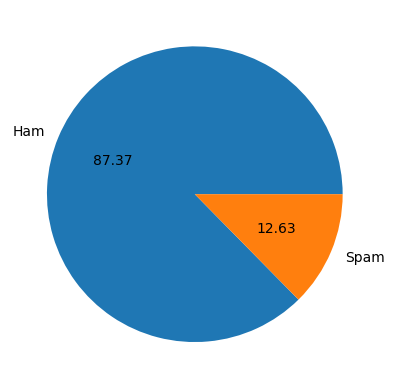

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(),labels=['Ham','Spam'],autopct="%0.2f")
plt.show()

In [18]:
import nltk

In [19]:
df['Text']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Text, Length: 5169, dtype: object

In [20]:
df['Text'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: Text, Length: 5169, dtype: int64

In [21]:
pd.options.mode.chained_assignment = None
df['Characters_length']=df['Text'].apply(len)

In [22]:
df.head()

,Target,Text,Characters_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
df['Word_length']=df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df.head()

,Target,Text,Characters_length,Word_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
df['Sentence_length']=df['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,Target,Text,Characters_length,Word_length,Sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df[['Characters_length','Word_length','Sentence_length']].describe()

,Characters_length,Word_length,Sentence_length
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
#For Ham Messages
df[df['Target']==0][['Characters_length','Word_length','Sentence_length']].describe()

,Characters_length,Word_length,Sentence_length
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
#For Spam Messages
df[df['Target']==1][['Characters_length','Word_length','Sentence_length']].describe()

,Characters_length,Word_length,Sentence_length
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [29]:
import seaborn as sn

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Characters_length', ylabel='Count'>

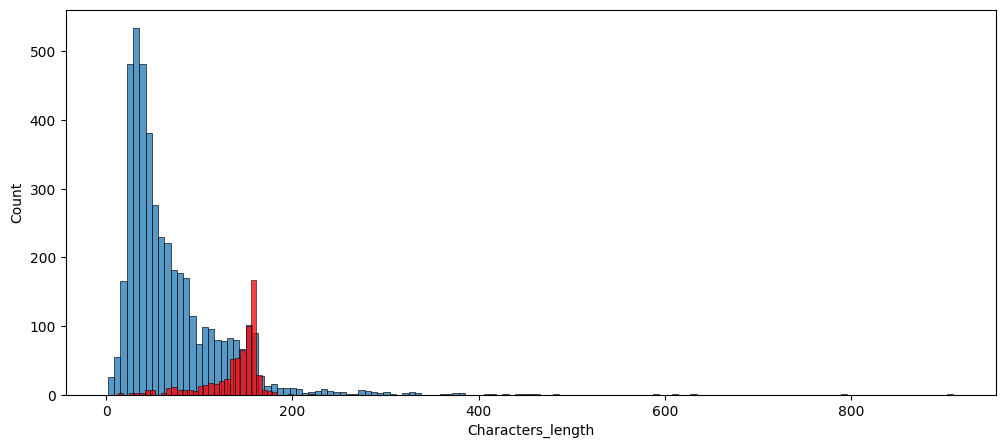

In [30]:
plt.figure(figsize=(12,5))
sn.histplot(df[df['Target']==0]['Characters_length'])
sn.histplot(df[df['Target']==1]['Characters_length'],color='red')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Word_length', ylabel='Count'>

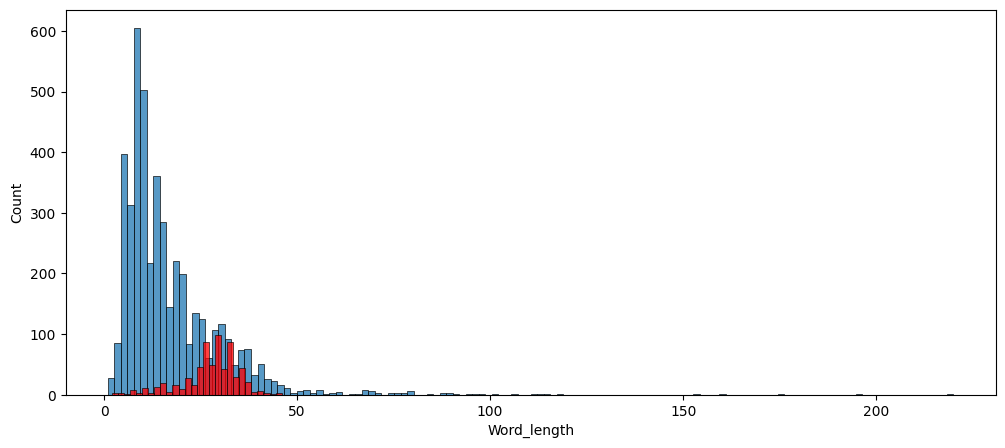

In [31]:
plt.figure(figsize=(12,5))
sn.histplot(df[df['Target']==0]['Word_length'])
sn.histplot(df[df['Target']==1]['Word_length'],color='red')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Sentence_length', ylabel='Count'>

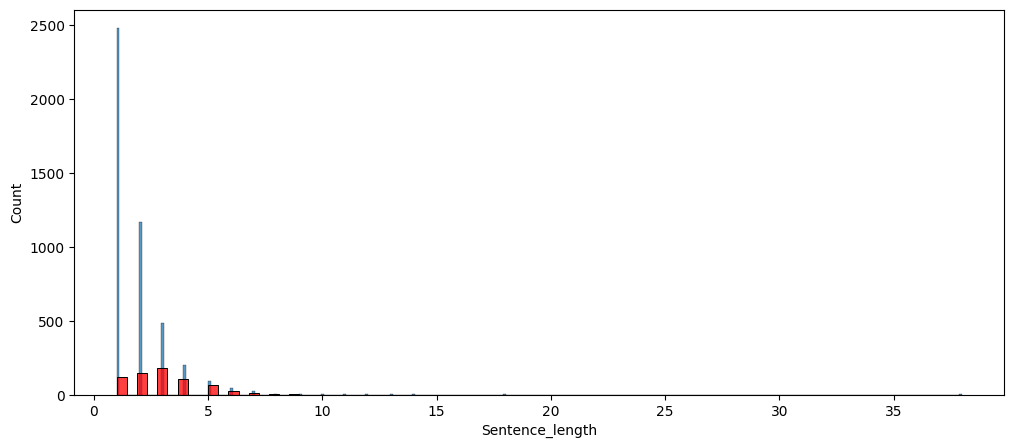

In [32]:
plt.figure(figsize=(12,5))
sn.histplot(df[df['Target']==0]['Sentence_length'])
sn.histplot(df[df['Target']==1]['Sentence_length'],color='red')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

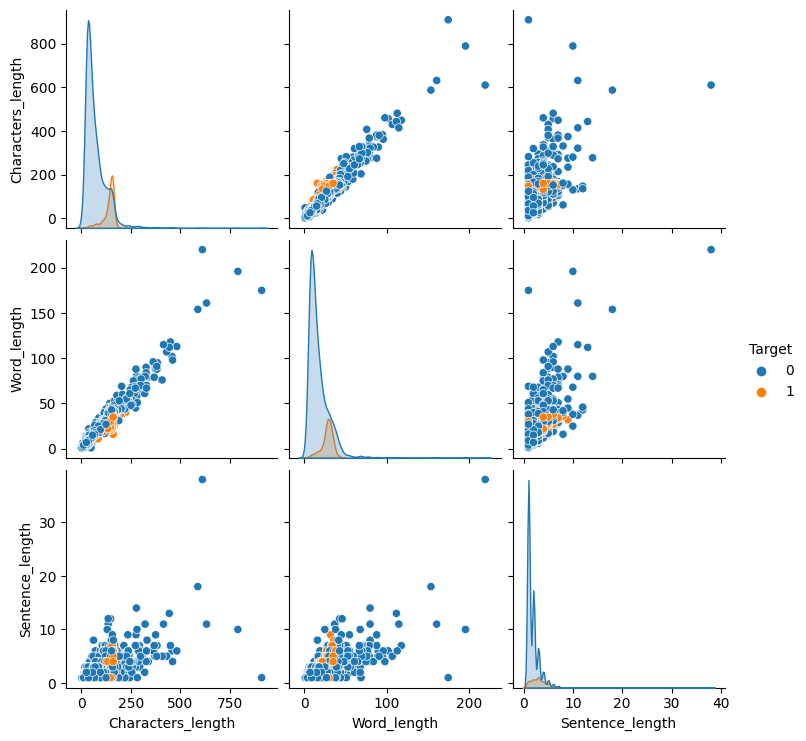

In [33]:
sn.pairplot(df,hue='Target')

In [34]:
df.head()

,Target,Text,Characters_length,Word_length,Sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


**Data Preprocessing**

In [35]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [36]:

def text_transform(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [37]:
text_transform('Loving')

'love'

In [38]:
df['Transformed_text']=df['Text'].apply(text_transform)

In [39]:
df.head()

,Target,Text,Characters_length,Word_length,Sentence_length,Transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=8,background_color='white')

In [41]:
spam_wc=wc.generate(df[df['Target']==1]['Transformed_text'].str.cat(sep=" "))

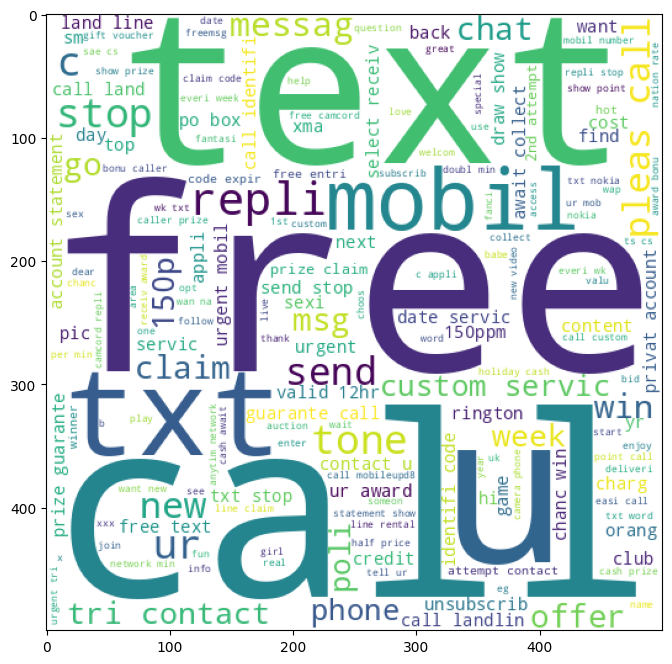

In [42]:
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)

In [43]:
ham_wc=wc.generate(df[df['Target']==0]['Transformed_text'].str.cat(sep=" "))

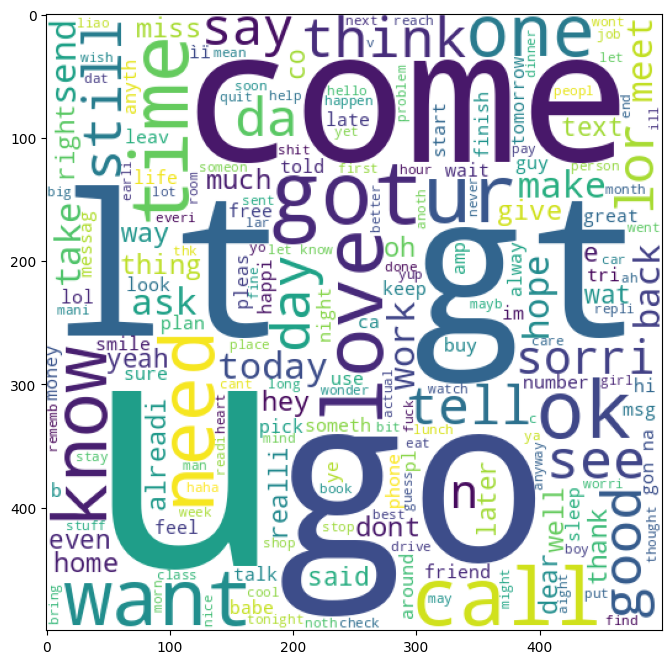

In [44]:
plt.figure(figsize=(12,8))
plt.imshow(ham_wc)

In [45]:
spam_corpus=[]
for msg in df[df['Target']==1]['Transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [46]:
ham_corpus=[]
for msg in df[df['Target']==0]['Transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [47]:
len(spam_corpus)
len(ham_corpus)

35404

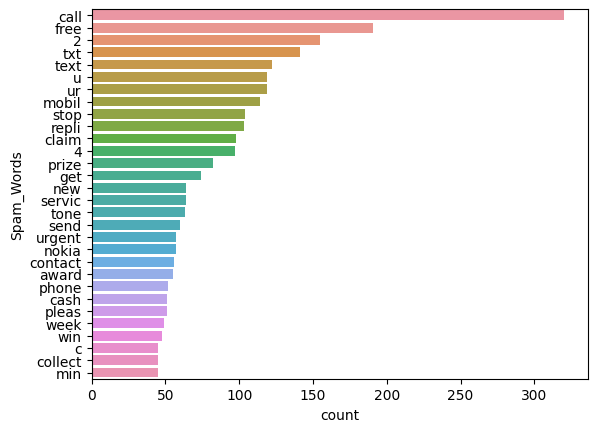

In [48]:
from collections import Counter
spam_word_counts = Counter(spam_corpus).most_common(30)
dframe1 = pd.DataFrame(spam_word_counts, columns=['Spam_Words', 'count'])
sn.barplot(x='count', y='Spam_Words', data=dframe1)
plt.show()

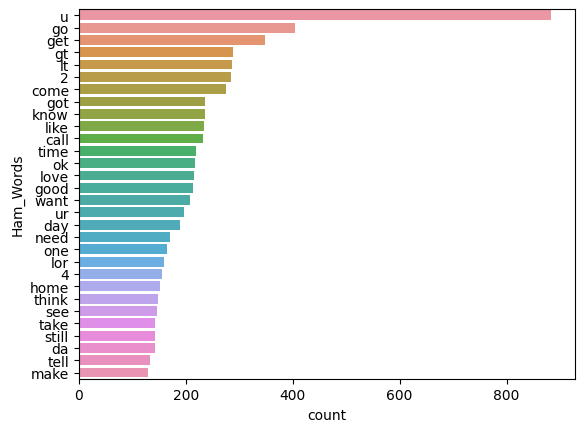

In [49]:
ham_word_counts = Counter(ham_corpus).most_common(30)
dframe2 = pd.DataFrame(ham_word_counts, columns=['Ham_Words', 'count'])
sn.barplot(x='count', y='Ham_Words', data=dframe2)
plt.show()

In [50]:
df.head()

,Target,Text,Characters_length,Word_length,Sentence_length,Transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Model BUilding**

In [51]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfid=TfidfVectorizer()

In [52]:
x=tfid.fit_transform(df['Transformed_text']).toarray()
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [53]:
y=df["Target"].values
y.shape

(5169,)

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [56]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [57]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gdbt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)
gb=GaussianNB()
mb=MultinomialNB()
bb=BernoulliNB()

In [58]:
clfs={
    'SVC':svc,
    'KNC':knc,
    'DTC':dtc,
    'LRC':lrc,
    'RFC':rfc,
    'ABC':abc,
    'BC':bc,
    'ETC':etc,
    'GDBT':gdbt,
    'XGB':xgb,
    'GB':gb,
    'MB':mb,
    'BB':bb
}

In [59]:
# y_train=y_train.ravel()
# y_test=y_test.ravel()
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return precision,accuracy

In [60]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9741379310344828, 0.9729206963249516)

In [61]:
accuracies=[]
precisions=[]
for name,clf in clfs.items():
    current_precision,current_accuracy=train_classifier(clf,x_train,y_train,x_test,y_test)
    print("For",name)
    print("Accuracy-",current_accuracy)
    print("Precision-",current_precision)

    accuracies.append(current_accuracy)
    precisions.append(current_precision)

For SVC
Accuracy- 0.9729206963249516
Precision- 0.9741379310344828
For KNC
Accuracy- 0.9003868471953579
Precision- 1.0
For DTC
Accuracy- 0.9361702127659575
Precision- 0.8461538461538461
For LRC
Accuracy- 0.9516441005802708
Precision- 0.94
For RFC
Accuracy- 0.971953578336557
Precision- 1.0
For ABC
Accuracy- 0.9613152804642167
Precision- 0.9454545454545454
For BC
Accuracy- 0.9584139264990329
Precision- 0.8625954198473282
For ETC
Accuracy- 0.9729206963249516
Precision- 0.9824561403508771
For GDBT
Accuracy- 0.9526112185686654
Precision- 0.9238095238095239
For XGB
Accuracy- 0.9729206963249516
Precision- 0.9435483870967742
For GB
Accuracy- 0.8762088974854932
Precision- 0.5231481481481481
For MB
Accuracy- 0.9593810444874274
Precision- 1.0
For BB
Accuracy- 0.9700193423597679
Precision- 0.9734513274336283


In [62]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracies,'Precision':precisions})

In [63]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.972921,0.974138
1,KNC,0.900387,1.000000
2,DTC,0.936170,0.846154
3,LRC,0.951644,0.940000
4,RFC,0.971954,1.000000
5,ABC,0.961315,0.945455
6,BC,0.958414,0.862595
7,ETC,0.972921,0.982456
8,GDBT,0.952611,0.923810
9,XGB,0.972921,0.943548


In [64]:
#voting classifier
svc=SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb=MultinomialNB()
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)

from sklearn.ensemble import VotingClassifier

In [65]:
voting=VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [66]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [67]:
y_pred=voting.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9787234042553191
1.0


In [68]:
#applying stacking
estimators=[('svm',svc),('nb',mnb),('et',etc)]
final_estimator=RandomForestClassifier()

In [69]:
from sklearn.ensemble import StackingClassifier

In [70]:
clf=StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [71]:
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9816247582205029
0.9612403100775194


In [75]:
import pickle
pickle.dump(tfid,open('vectorizer.pkl','wb'))
model=MultinomialNB()
model.fit(x_train,y_train)
pickle.dump(model,open('spam-model.pkl','wb'))